In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import vima
import gc, os
import scanpy as sc
import cna
import pickle

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import torch
torch.set_default_device('mps') # for running on Yakir's macbook's GPU, change to cuda for O2

In [ ]:
def run(P, Pdense, dsetname, models, modelname,
        sample_aware=False, variational=False, train=True):
    # remove sample info from the training data if necessary
    realPmeta = P.meta.copy()
    realPdensemeta = Pdense.meta.copy()
    if not sample_aware:
        P.meta['sid'] = P.meta.sid[0]
        P.meta['sid_num'] = 0
        Pdense.meta['sid'] = Pdense.meta.sid[0]
        Pdense.meta['sid_num'] = 0

    if not variational:
        for model in models:
            model.variational = False

    # train if necessary
    if train:
        log = vima.train(models, P, n_epochs=10,
                        kl_weight=(1e-5 if variational else 0))
        torch.save(models.state_dict(), f'_models/{dsetname}_{modelname}-1all.pt')
        log2 = vima.train(models, Pdense, n_epochs=20,
                        kl_weight=(1e-5 if variational else 0))
        torch.save(models.state_dict(), f'_models/{dsetname}_{modelname}-2dense.pt')
    models.load_state_dict(torch.load(f'_models/{dsetname}_{modelname}-2dense.pt'))

    # generate latent representations
    ds = vima.latentreps(models, Pdense)

    # re-insert sample ids
    for d in ds:
        d.obs['sid'] = realPdensemeta.sid
    P.meta = realPmeta
    Pdense.meta = realPdensemeta

    # save
    pickle.dump(ds, open(f'_models/{dsetname}_{modelname}.pkl', 'wb'))

# RA

In [25]:
# read in samples
def fname_parser(fname):
    fname = fname.split('/')[-1].split('.nc')[0]
    return {
        'donor': fname.split('_')[0].replace('Repeat',''),
        'sid': fname
    }
repname = 'pca_k=5_harmony'
samples = vima.read_samples(f'../../RA/BHAM-data/10u/{repname}/*.nc', fname_parser)

# read in and reformat sample metadata
fullmeta = pd.read_csv('../../RA/BHAM-data/ihc-metadata.csv').set_index('subject_id')[['CTAP']]
fullmeta.index = fullmeta.index.str.replace('V0', '')
fullmeta = pd.merge(fullmeta, pd.get_dummies(fullmeta.CTAP.str.replace(' + ', ''), prefix='', prefix_sep=''),
        left_index=True, right_index=True)
fullmeta['fstar'] = fullmeta.F | fullmeta.TF | fullmeta.EFM

# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.2, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

# change samplemeta so that each row is a sample rather than a donor
inourdata = P.meta[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, fullmeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta.F | samplemeta.TF | samplemeta.EFM

100%|███████████████████████████████████████████████████████████████| 27/27 [00:07<00:00,  3.57it/s]


in pytorch mode
means: [-0.05244613 -0.03230551 -0.00229227 -0.02602132  0.00177607]
stds: [0.78998685 0.78190607 0.7570089  0.5288024  0.39285856]
data augmentation is off
39302 patches


100%|███████████████████████████████████████████████████████████████| 27/27 [00:04<00:00,  6.29it/s]


in pytorch mode
means: [-0.01986517  0.01846761  0.16045094  0.01280896  0.03556773]
stds: [1.0030473  1.0236274  0.97415096 0.68447864 0.53854287]
data augmentation is off
10345 dense patches


end of epoch 20: avg val loss = 0.7467096269130706
time elapsed this epoch: 83.49 sec
total time elapsed: 1671.65 sec


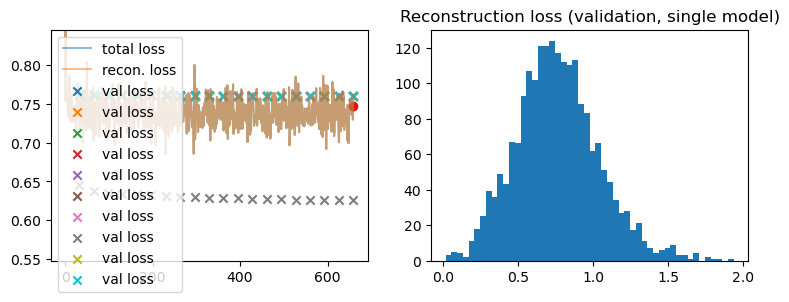

best validation losses so far across full model ensemble: [0.76015633, 0.7601337, 0.7601479, 0.7601146, 0.7601509, 0.7600946, 0.7601031, 0.6257034, 0.7601259, 0.7601832]
best epochs so far across full model ensemble: [17, 20, 20, 19, 18, 20, 19, 20, 20, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 11/11 [00:11<00:00,  1.05s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:22<00:00,  2.21s/it]


In [ ]:
models = torch.nn.ModuleList([
            vima.models.SimpleVAE(P.nmarkers, 40)
            for _ in range(10)])
run(P, Pdense, 'RA', models, 'vima-nocvae-noresnet', sample_aware=False, variational=False, train=True)

end of epoch 20: avg val loss = 0.5772971451282501
time elapsed this epoch: 95.52 sec
total time elapsed: 1913.80 sec


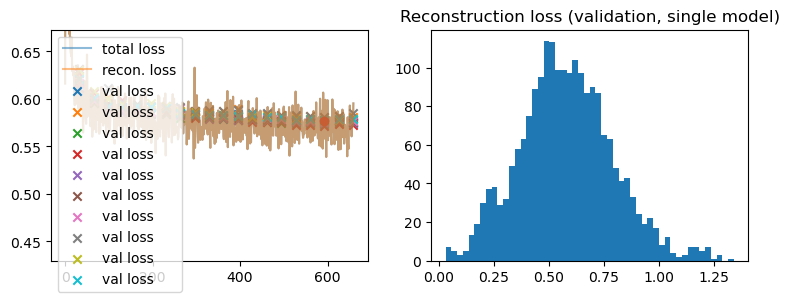

best validation losses so far across full model ensemble: [0.5757342, 0.5807669, 0.5738591, 0.5714686, 0.57479024, 0.57557034, 0.5759394, 0.5811108, 0.57754797, 0.5775386]
best epochs so far across full model ensemble: [20, 20, 18, 18, 20, 20, 18, 18, 18, 18]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 11/11 [00:08<00:00,  1.35it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:11<00:00,  1.15s/it]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'RA', models, 'vima-nocvae', sample_aware=False, variational=False, train=True)

end of epoch 20: avg val loss = 0.5730558574199677
time elapsed this epoch: 98.34 sec
total time elapsed: 1965.95 sec


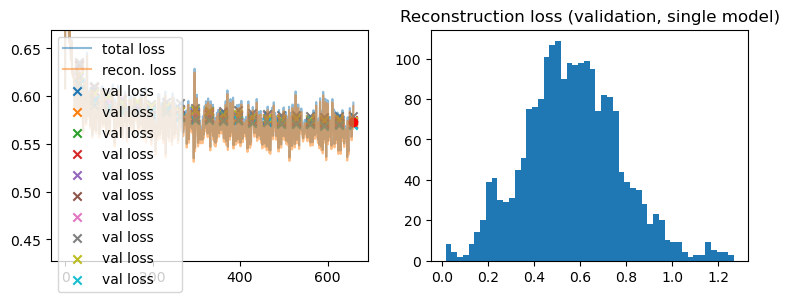

best validation losses so far across full model ensemble: [0.57107353, 0.5727982, 0.57027495, 0.57443035, 0.57114065, 0.5736307, 0.5742681, 0.57846385, 0.5743677, 0.568927]
best epochs so far across full model ensemble: [20, 20, 18, 20, 18, 20, 20, 18, 20, 18]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 11/11 [00:07<00:00,  1.40it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:12<00:00,  1.25s/it]


In [26]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'RA', models, 'vima-nosid', sample_aware=False, variational=True, train=True)

In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'RA', models, 'vima', sample_aware=True, variational=True, train=False)

In [27]:
del P; del Pdense; del samples
gc.collect()

1186

# UC

In [28]:
# read in samples
def fname_parser(fname): 
    fname = fname.split("/")[-1].split(".nc")[0]
    if fname[-1].islower():
        donor = fname[:-1]
    else: 
        donor = fname
    return {'sid': fname, 'donor': donor}

repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../UC/UC-data/10u/{repname}/*.nc', fname_parser)

# read in sample metadata
samplemeta = pd.read_csv('../../UC/UC-data/2024_10_16_UC_Patient_Metadata.csv').rename(columns={'NEW Label':'sid', 'Patient.ID':'donor'}).set_index('sid', drop=True)
samplemeta.donor = samplemeta.donor.astype('str')
samplemeta['case'] = (samplemeta.Status == 'UC').astype('float')
samplemeta.loc[(samplemeta.TNFnow == 'y') | (samplemeta.TNFprior == 'y'), 'case'] = np.nan

# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

100%|███████████████████████████████████████████████████████████████| 42/42 [00:03<00:00, 12.69it/s]


in pytorch mode
means: [ 0.10416503  0.0328176  -0.01539105 -0.05837893 -0.05422029  0.00433627
  0.00879668 -0.0906005   0.01674931  0.04970502]
stds: [2.775768   1.6161621  1.5296637  0.98521984 0.7064063  0.69478464
 0.85681117 0.7094363  0.8510031  0.7016911 ]
data augmentation is off
25869 patches


100%|███████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 16.19it/s]


in pytorch mode
means: [ 0.08236497  0.01278561 -0.03404242 -0.06953852 -0.06287906 -0.00149564
  0.01076982 -0.10602119  0.00874166  0.04395668]
stds: [2.911888   1.7142467  1.6148511  1.0411712  0.7507614  0.7380631
 0.90177256 0.75123715 0.88954216 0.741207  ]
data augmentation is off
21359 dense patches


end of epoch 20: avg val loss = 0.8512807250022888
time elapsed this epoch: 151.27 sec
total time elapsed: 3025.25 sec


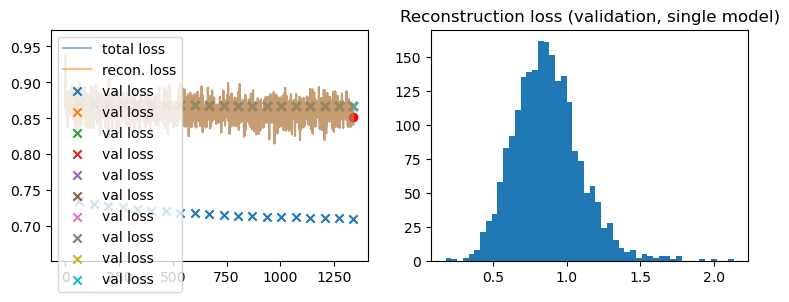

best validation losses so far across full model ensemble: [0.7100426, 0.8669775, 0.8670116, 0.8669668, 0.86702037, 0.8669552, 0.86690176, 0.86698884, 0.8669462, 0.866891]
best epochs so far across full model ensemble: [20, 20, 20, 18, 20, 20, 20, 16, 18, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:24<00:00,  1.12s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.60s/it]


In [ ]:
models = torch.nn.ModuleList([
            vima.models.SimpleVAE(P.nmarkers, 40)
            for _ in range(10)])
run(P, Pdense, 'UC', models, 'vima-nocvae-noresnet', sample_aware=False, variational=False, train=True)

end of epoch 20: avg val loss = 0.655552077293396
time elapsed this epoch: 176.30 sec
total time elapsed: 3528.13 sec


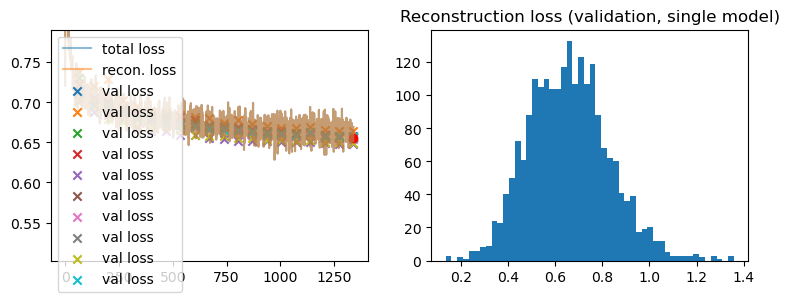

best validation losses so far across full model ensemble: [0.65772784, 0.6635537, 0.65623754, 0.6569312, 0.64805716, 0.65628517, 0.6544633, 0.6557297, 0.64967, 0.6568651]
best epochs so far across full model ensemble: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:16<00:00,  1.32it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.78s/it]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'UC', models, 'vima-nocvae', sample_aware=False, variational=False, train=True)

end of epoch 20: avg val loss = 0.644530427455902
time elapsed this epoch: 177.66 sec
total time elapsed: 3556.19 sec


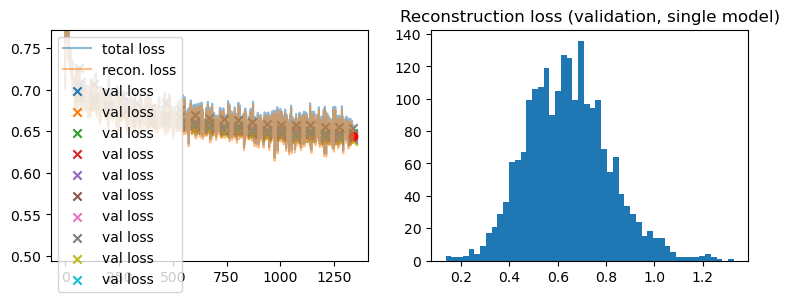

best validation losses so far across full model ensemble: [0.6439801, 0.6454026, 0.6471758, 0.6447575, 0.64136505, 0.63886434, 0.6450501, 0.6540302, 0.63827723, 0.64433134]
best epochs so far across full model ensemble: [19, 20, 19, 19, 20, 18, 20, 20, 20, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:16<00:00,  1.35it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:19<00:00,  1.93s/it]


In [29]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'UC', models, 'vima-nosid', sample_aware=False, variational=True, train=True)

end of epoch 20: avg val loss = 0.871944373846054
time elapsed this epoch: 152.65 sec
total time elapsed: 3042.73 sec


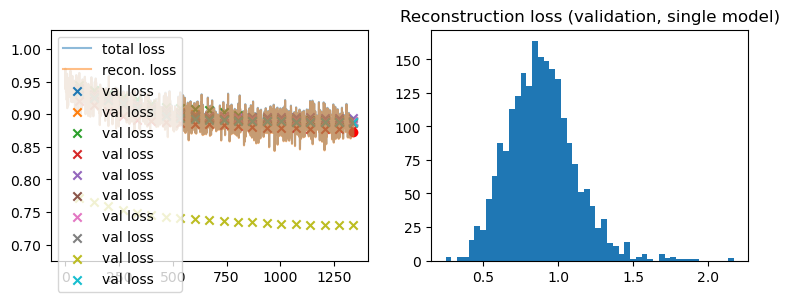

best validation losses so far across full model ensemble: [0.88958865, 0.8874481, 0.88987225, 0.876764, 0.89458036, 0.88792706, 0.8893928, 0.8868405, 0.7293093, 0.88772064]
best epochs so far across full model ensemble: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:24<00:00,  1.11s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.56s/it]


In [30]:
models = torch.nn.ModuleList([
            vima.models.SimpleVAE(P.nmarkers, 40)
            for _ in range(10)])
run(P, Pdense, 'UC', models, 'vima-nosid-noresnet', sample_aware=False, variational=True, train=True)

In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'UC', models, 'vima', sample_aware=True, variational=True, train=False)

In [10]:
del P; del Pdense; del samples
gc.collect()

1163

# ALZ

In [31]:
# read in samples
repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../ALZ/alz-data/10u/{repname}/*.nc', vima.default_parser)

# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

# change samplemeta so that each row is a sample rather than a donor
samplemeta = pd.read_csv('../../ALZ/alz-data/sea-ad_cohort_donor_metadata_encoded_20240924.tsv',
                         sep='\t').set_index('Donor ID', drop=True)
inourdata = P.meta[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, samplemeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)
samplemeta['case'] = samplemeta['Consensus Clinical Dx (choice=Control)'] != 'Checked'
samplemeta = samplemeta[['donor','case']]

100%|███████████████████████████████████████████████████████████████| 75/75 [00:22<00:00,  3.28it/s]


in pytorch mode
means: [ 0.02969506  0.01661549  0.00888635  0.01188825  0.06803574 -0.03225867
 -0.0028971  -0.04082257  0.01312019 -0.00887914]
stds: [1.4078783  1.2038424  1.0248318  0.95188147 0.8705225  0.881165
 0.92391837 0.79876465 0.77549326 0.7532553 ]
data augmentation is off
172202 patches


100%|███████████████████████████████████████████████████████████████| 75/75 [00:11<00:00,  6.80it/s]


in pytorch mode
means: [ 0.26591253  0.01705899 -0.02094378  0.08837456  0.0851762  -0.03347326
  0.03390069 -0.06034963  0.00104615 -0.00660841]
stds: [1.4897596  1.3238777  1.1583116  1.0943227  0.998182   1.0070941
 1.0188577  0.92440414 0.880947   0.889983  ]
data augmentation is off
70898 dense patches


end of epoch 20: avg val loss = 1.0699871301651
time elapsed this epoch: 434.06 sec
total time elapsed: 9176.33 sec


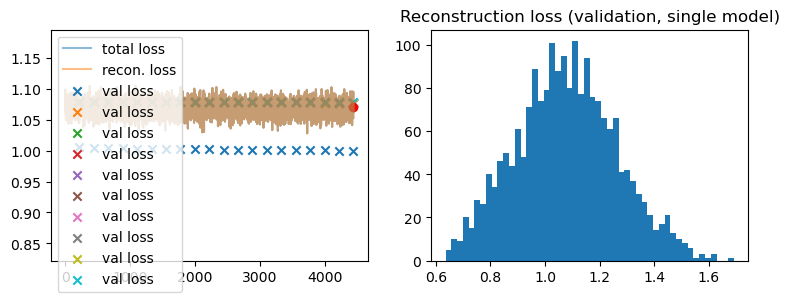

best validation losses so far across full model ensemble: [1.0000018, 1.0777558, 1.0777551, 1.0777551, 1.0777452, 1.0777589, 1.0777549, 1.0777601, 1.0777563, 1.0777655]
best epochs so far across full model ensemble: [19, 20, 19, 20, 20, 20, 20, 19, 18, 19]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 71/71 [01:21<00:00,  1.15s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.61s/it]


In [ ]:
models = torch.nn.ModuleList([
            vima.models.SimpleVAE(P.nmarkers, 40)
            for _ in range(10)])
run(P, Pdense, 'ALZ', models, 'vima-nocvae-noresnet', sample_aware=False, variational=False, train=True)

end of epoch 20: avg val loss = 0.9275923669338226
time elapsed this epoch: 545.82 sec
total time elapsed: 13539.81 sec


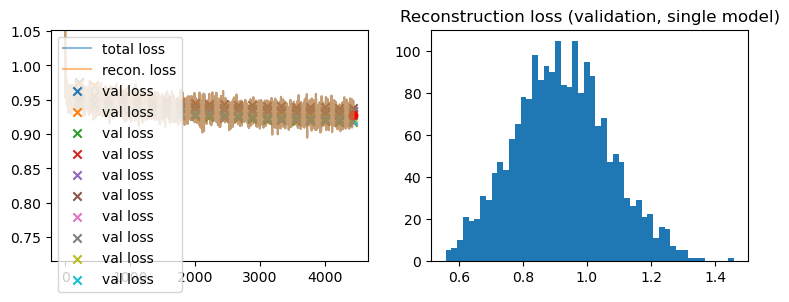

best validation losses so far across full model ensemble: [0.92911774, 0.92997193, 0.9173492, 0.93324065, 0.9308866, 0.9384786, 0.91940176, 0.9332215, 0.9234221, 0.9208335]
best epochs so far across full model ensemble: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 71/71 [00:54<00:00,  1.31it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:56<00:00,  5.67s/it]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'ALZ', models, 'vima-nocvae', sample_aware=False, variational=False, train=True)

In [24]:
models = vima.models.cVAE(P.nmarkers, 1)
run(P, Pdense, 'ALZ', models, 'vima-nosid', sample_aware=False, variational=True, train=False)

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 71/71 [00:54<00:00,  1.31it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:59<00:00,  5.92s/it]


end of epoch 20: avg val loss = 1.073094403743744
time elapsed this epoch: 508.24 sec
total time elapsed: 10818.70 sec


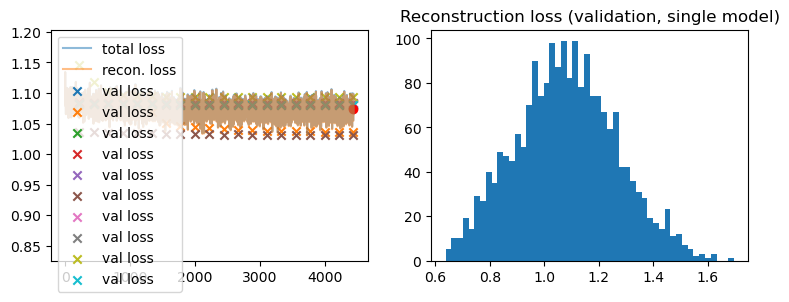

best validation losses so far across full model ensemble: [1.0821705, 1.0365326, 1.0812678, 1.0828333, 1.0828736, 1.0309371, 1.0804328, 1.0804545, 1.0930055, 1.0803776]
best epochs so far across full model ensemble: [20, 20, 20, 20, 19, 20, 20, 20, 20, 19]
applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 71/71 [01:44<00:00,  1.47s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:50<00:00,  5.01s/it]


In [32]:
models = torch.nn.ModuleList([
            vima.models.SimpleVAE(P.nmarkers, 40)
            for _ in range(10)])
run(P, Pdense, 'ALZ', models, 'vima-nosid-noresnet', sample_aware=False, variational=True, train=True)

In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)
run(P, Pdense, 'ALZ', models, 'vima', sample_aware=True, variational=True, train=False)

In [14]:
del P; del Pdense; del samples
gc.collect()

1163